# Cuadernillo noticias falsas: AI Incident Database

Este cuadernillo genera un dataset reproducible a partir de los snapshots públicos de AIID y analiza incidentes relacionados con noticias falsas, información errónea, desinformación, deepfake y contenidos manipulados.

Fuente: https://incidentdatabase.ai/research/snapshots/


In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

candidatos = [
    Path('Dataset/Data_set_07.csv'),
    Path('../Dataset/Data_set_07.csv'),
    Path('../../Dataset/Data_set_07.csv'),
]
DATASET = next(path for path in candidatos if path.exists())
df = pd.read_csv(DATASET, parse_dates=['incident_date', 'first_report_date', 'last_report_date'])
anio_inicio = 2018
anio_fin = 2025
df_analisis = df[df['year'].between(anio_inicio, anio_fin, inclusive='both')].copy()
df.head()


,incident_id,incident_date,year,title,description,reports_count,first_report_date,last_report_date,source_domains,Alleged deployer of AI system,Alleged developer of AI system,Alleged harmed or nearly harmed parties,Harm Domain,AI Harm Level,Sector of Deployment,Location Region,matching_terms
0,263,2015-09-01,2015,YouTube Recommendations Implicated in Politica...,YouTube’s personalization and recommendation a...,1,2019-06-08 00:00:00+00:00,2019-06-08 00:00:00+00:00,nytimes.com,youtube,youtube,youtube-young-male-users; youtube-male-users; ...,NaN,NaN,NaN,NaN,misinformation
1,476,2015-11-13,2015,YouTube Recommendations Allegedly Promoted Rad...,Family of Nohemi Gonzalez alleged YouTube reco...,3,2022-10-03 00:00:00+00:00,2023-02-23 00:00:00+00:00,bipartisanpolicy.org; forbes.com; scotusblog.com,youtube,youtube,victims-in-paris-attacks; nohemi-gonzalez-fami...,maybe,unclear,information and communication,Europe,propaganda
2,496,2017-03-01,2017,Male College Freshman Allegedly Made Porn Deep...,A female college student's face was superimpos...,2,2023-03-11 00:00:00+00:00,2023-03-13 00:00:00+00:00,thedailybeast.com; yahoo.com,unnamed-male-college-student,unknown,unnamed-female-college-student,NaN,NaN,NaN,NaN,deepfake
3,39,2017-07-01,2017,Deepfake Obama Introduction of Deepfakes,University of Washington researchers made a de...,29,2017-07-12 00:00:00+00:00,2018-09-11 00:00:00+00:00,abc.net.au; bbc.com; blackenterprise.com; cnet...,university-of-washington; fakeapp,university-of-washington; fakeapp,barack-obama,no,none,"Arts, entertainment and recreation, profession...",North America,fake news; deepfake
4,769,2018-04-20,2018,Investigative Journalist Rana Ayyub Targeted b...,Investigative journalist Rana Ayyub was target...,2,2018-11-21 00:00:00+00:00,2020-05-11 00:00:00+00:00,huffingtonpost.co.uk; lawfaremedia.org,unknown-deepfake-creators,unknown-deepfake-technology-developers,rana-ayyub,NaN,NaN,NaN,NaN,deepfake


## Resumen del dataset generado

- Registros filtrados en el CSV: 461
- Cantidad de datos usados en los gráficos: 433 incidentes
- Período elegido para análisis visual: 2018 a 2025
- Período cubierto: 2015 a 2026
- Período usado en gráficos: 2018 a 2025
- Archivo CSV: `Dataset/Data_set_07.csv`
- Gráficos exportados: carpeta `graficos/`


In [6]:
resumen = df[['incident_id', 'incident_date', 'title', 'reports_count', 'source_domains', 'matching_terms']]
resumen.sort_values('incident_date').head(10)


,incident_id,incident_date,title,reports_count,source_domains,matching_terms
0,263,2015-09-01,YouTube Recommendations Implicated in Politica...,1,nytimes.com,misinformation
1,476,2015-11-13,YouTube Recommendations Allegedly Promoted Rad...,3,bipartisanpolicy.org; forbes.com; scotusblog.com,propaganda
2,496,2017-03-01,Male College Freshman Allegedly Made Porn Deep...,2,thedailybeast.com; yahoo.com,deepfake
3,39,2017-07-01,Deepfake Obama Introduction of Deepfakes,29,abc.net.au; bbc.com; blackenterprise.com; cnet...,fake news; deepfake
4,769,2018-04-20,Investigative Journalist Rana Ayyub Targeted b...,2,huffingtonpost.co.uk; lawfaremedia.org,deepfake
5,164,2018-10-01,"Facebook ""News Feed"" Allegedly Boosted Misinfo...",1,wsj.com,misinformation
6,653,2019-01-01,Two Investment Firms Charged with Making False...,1,sec.gov,false claim; false claims
7,305,2019-02-01,YouTube’s Recommendation Algorithm Allegedly P...,2,axios.com; secure.avaaz.org,misinformation
8,471,2019-06-22,Facebook Allegedly Failed to Police Hate Speec...,8,accessnow.org; advox.globalvoices.org; bbc.com...,disinformation
9,530,2019-07-11,Telegram Channels Allowed Users to Make Non-Co...,3,technologyreview.com; theverge.com,deepfake


In [7]:
conteo_anual = df_analisis.groupby('year').size().reset_index(name='incidentes')
conteo_anual


,year,incidentes
0,2018,2
1,2019,4
2,2020,14
3,2021,7
4,2022,15
5,2023,67
6,2024,136
7,2025,188


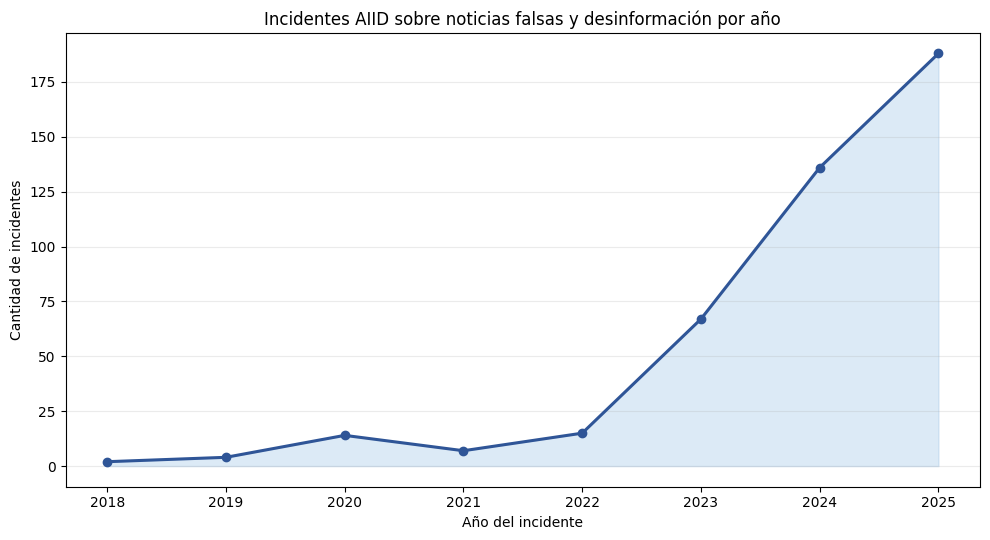

In [8]:
plt.figure(figsize=(10, 5.5))
plt.plot(conteo_anual['year'], conteo_anual['incidentes'], marker='o', color='#2f5597', linewidth=2.2)
plt.fill_between(conteo_anual['year'], conteo_anual['incidentes'], color='#9dc3e6', alpha=0.35)
plt.title('Incidentes AIID sobre noticias falsas y desinformación por año')
plt.xlabel('Año del incidente')
plt.ylabel('Cantidad de incidentes')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


In [9]:
def contar_valores(columna, datos=df_analisis):
    valores = []
    for item in datos[columna].dropna():
        valores.extend([v.strip() for v in str(item).split(';') if v.strip()])
    return pd.Series(valores).value_counts()

contar_valores('source_domains').head(10)


nytimes.com           42
theguardian.com       37
washingtonpost.com    31
bbc.com               24
reuters.com           21
cbsnews.com           18
wired.com             15
theverge.com          14
dailymail.co.uk       14
nbcnews.com           14
Name: count, dtype: int64

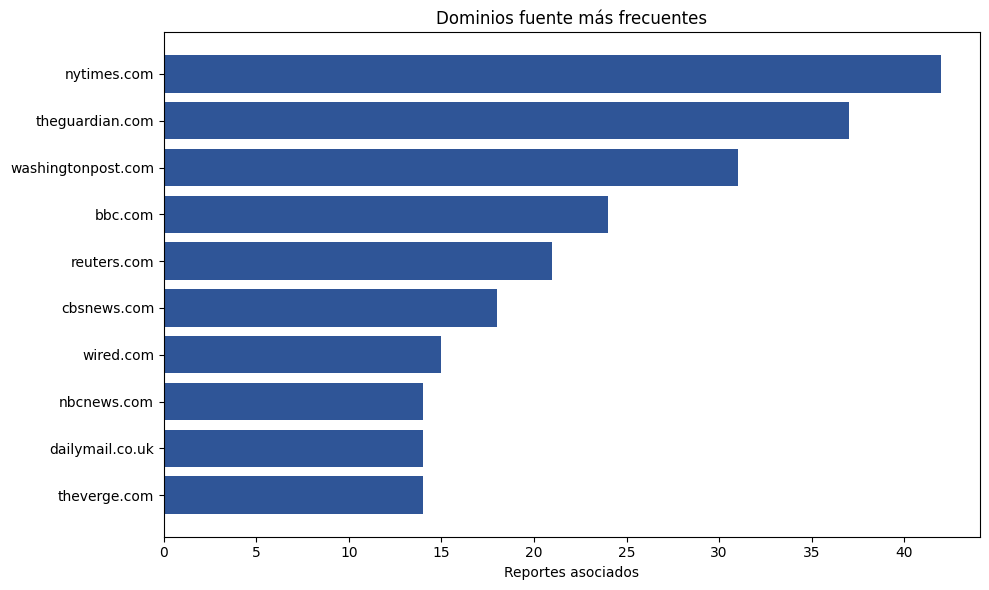

In [10]:
top_dominios = contar_valores('source_domains', df_analisis).head(10).sort_values()
plt.figure(figsize=(10, 6))
plt.barh(top_dominios.index, top_dominios.values, color='#2f5597')
plt.title('Dominios fuente más frecuentes')
plt.xlabel('Reportes asociados')
plt.tight_layout()
plt.show()


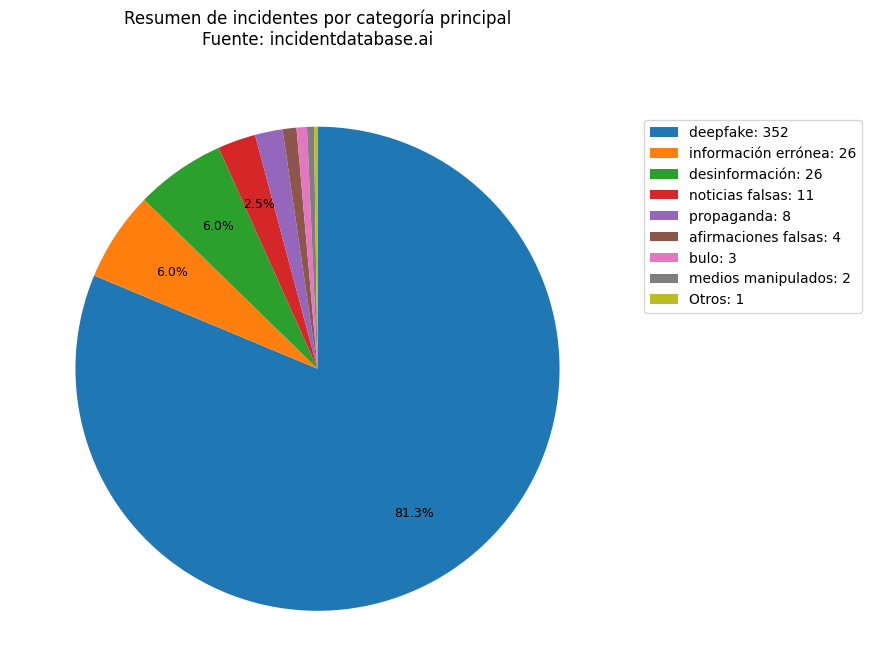

In [11]:
etiquetas_terminos = {
    'fake news': 'noticias falsas',
    'misinformation': 'información errónea',
    'disinformation': 'desinformación',
    'deepfake': 'deepfake',
    'deep fake': 'deepfake',
    'synthetic media': 'medios sintéticos',
    'manipulated media': 'medios manipulados',
    'false information': 'noticias falsas',
    'false claim': 'afirmaciones falsas',
    'false claims': 'afirmaciones falsas',
    'hoax': 'bulo',
    'propaganda': 'propaganda',
    'election misinformation': 'desinformación electoral',
}
prioridad_categorias = [
    'deepfake',
    'desinformación',
    'información errónea',
    'noticias falsas',
    'afirmaciones falsas',
    'propaganda',
    'medios manipulados',
    'bulo',
    'medios sintéticos',
    'desinformación electoral',
]
categorias_principales = []
for item in df_analisis['matching_terms'].dropna():
    categorias = {
        etiquetas_terminos.get(v.strip(), v.strip())
        for v in str(item).split(';')
        if v.strip()
    }
    for categoria in prioridad_categorias:
        if categoria in categorias:
            categorias_principales.append(categoria)
            break

conteo_terminos = pd.Series(categorias_principales).value_counts()
top_terms = conteo_terminos.head(8)
otros = conteo_terminos.iloc[8:].sum()
if otros > 0:
    top_terms.loc['Otros'] = otros

fig, ax = plt.subplots(figsize=(10, 7.5))
wedges, texts, autotexts = ax.pie(
    top_terms.values,
    labels=None,
    autopct=lambda pct: f'{pct:.1f}%' if pct >= 2 else '',
    startangle=90,
    counterclock=False,
    pctdistance=0.72,
    textprops={'fontsize': 9},
)
ax.set_title(
    'Resumen de incidentes por categoría principal\nFuente: incidentdatabase.ai',
    pad=26,
    y=1.04,
)
ax.legend(
    wedges,
    [f'{label}: {value}' for label, value in zip(top_terms.index, top_terms.values)],
    loc='upper left',
    bbox_to_anchor=(1.02, 0.98),
    frameon=True,
)
ax.axis('equal')
fig.subplots_adjust(top=0.82, right=0.74)
plt.show()


## Nota metodológica

El filtro usa palabras clave en títulos, descripciones y reportes asociados al incidente. Por eso el CSV debe leerse como un subconjunto temático para exploración e informe, no como una taxonomía oficial exhaustiva de AIID.

Para los gráficos se usa el período 2018-2025. Se excluye 2026 porque es un año incompleto en el snapshot usado; también se dejan fuera los años previos a 2018 para que la tendencia reciente de desinformación asociada a IA se observe con mayor claridad.
